In [ ]:
# Installing Dependent Libraries
!pip install tensorflow keras numpy matplotlib scikit-learn opencv-python pandas
!pip install elpv-dataset # For easy access to the dataset

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.8/90.8 MB 6.6 MB/s eta 0:00:00


Loaded 2624 images.
Image shape: (300, 300)
Defect probabilities (unique values): [0.         0.33333333 0.66666667 1.        ]
Module types (unique values): ['mono' 'poly']


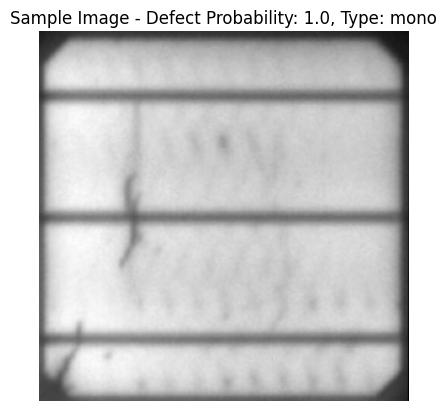

In [ ]:
# Data Acquisition

import numpy as np
import matplotlib.pyplot as plt
from elpv_dataset.utils import load_dataset

# Load the dataset
# images: numpy array of shape (2624, 300, 300) containing grayscale images
# proba: numpy array of shape (2624,) containing defect probabilities (0.0, 0.33, 0.66, 1.0)
# types: list of strings indicating 'mono' or 'poly' for each image
images, proba, types = load_dataset()

print(f"Loaded {len(images)} images.")
print(f"Image shape: {images[0].shape}")
print(f"Defect probabilities (unique values): {np.unique(proba)}")
print(f"Module types (unique values): {np.unique(types)}")

# Display a sample image
plt.imshow(images[0], cmap='gray')
plt.title(f"Sample Image - Defect Probability: {proba[0]}, Type: {types[0]}")
plt.axis('off')
plt.show()

In [ ]:
# 3. Data Preprocessing and Feature Engineering

# 3.1. Resizing and Normalization
import cv2

IMG_SIZE = 224 # Standard input size for VGG16/ResNet

# Resize and normalize images
processed_images = []
for img in images:
    resized_img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    normalized_img = resized_img / 255.0 # Normalize pixel values to [0, 1]
    processed_images.append(normalized_img)

processed_images = np.array(processed_images)

# Expand dimensions for grayscale images to be compatible with CNN input (batch, height, width, channels)
# For grayscale, channels = 1
processed_images = np.expand_dims(processed_images, axis=-1)

print(f"Processed images shape: {processed_images.shape}")

# 3.2. Label Preparation (Classification Task)
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Define thresholds for binary classification (Defective vs. Functional)
# You can adjust this threshold based on your project's sensitivity requirements
defect_threshold = 0.0 # Any probability > 0.0 is considered defective

# Create binary labels: 1 for defective, 0 for functional
binary_labels = (proba > defect_threshold).astype(int)

# Convert labels to one-hot encoding for Keras (if using categorical_crossentropy)
# For binary classification with sigmoid output, you might not need one-hot encoding
# but it's good practice for multi-class or if you switch to softmax for binary
num_classes = len(np.unique(binary_labels))
one_hot_labels = to_categorical(binary_labels, num_classes=num_classes)

print(f"Binary labels (sample): {binary_labels[:10]}")
print(f"One-hot labels (sample): {one_hot_labels[:10]}")

# Split data into training, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(processed_images, one_hot_labels, test_size=0.2, random_state=42, stratify=binary_labels)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train) # 0.25 of 0.8 is 0.2

print(f"Train set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")

# 3.3. Advanced Feature Engineering: Data Augmentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_augmenter = ImageDataGenerator(
    rotation_range=20,        # Rotate images by up to 20 degrees
    width_shift_range=0.1,    # Shift images horizontally by 10% of width
    height_shift_range=0.1,   # Shift images vertically by 10% of height
    shear_range=0.1,          # Apply shear transformation
    zoom_range=0.1,           # Zoom in/out by 10%
    horizontal_flip=True,     # Flip images horizontally
    fill_mode='nearest'       # Fill in new pixels created by transformations
)

# Fit the augmenter on the training data
data_augmenter.fit(X_train)

# You can now use data_augmenter.flow(X_train, y_train, batch_size=32) during training

Processed images shape: (2624, 224, 224, 1)
Binary labels (sample): [1 1 1 0 1 1 1 1 0 1]
One-hot labels (sample): [[0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]]
Train set size: 1574
Validation set size: 525
Test set size: 525


In [ ]:
# 4. Model Architecture (Transfer Learning with VGG-16 or ResNet50)

# 4.1. VGG-16 Based Model
# =========================================================
# 4. Model Architecture (Transfer Learning using VGG16)
# =========================================================

import tensorflow as tf

from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import (
    Input,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    Concatenate
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# ---------------------------------------------------------
# Define Input Shape
# ---------------------------------------------------------
# Grayscale image input
input_shape = (IMG_SIZE, IMG_SIZE, 1)

# Number of classes
# Example:
# num_classes = 2
# (Defective / Non-Defective)

# ---------------------------------------------------------
# Create Input Layer
# ---------------------------------------------------------
input_tensor = Input(shape=input_shape)

# ---------------------------------------------------------
# Convert 1-Channel Grayscale to 3-Channel
# VGG16 requires RGB input
# ---------------------------------------------------------
x = Concatenate(axis=-1)(
    [input_tensor, input_tensor, input_tensor]
)

# ---------------------------------------------------------
# Load Pretrained VGG16 Model
# ---------------------------------------------------------
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_tensor=x
)

# ---------------------------------------------------------
# Freeze Pretrained Layers
# ---------------------------------------------------------
for layer in base_model.layers:
    layer.trainable = False

# ---------------------------------------------------------
# Custom Classification Head
# ---------------------------------------------------------
x = base_model.output

x = Flatten()(x)

x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Output Layer
predictions = Dense(
    num_classes,
    activation='softmax'
)(x)

# ---------------------------------------------------------
# Final Model
# ---------------------------------------------------------
model = Model(
    inputs=base_model.input,
    outputs=predictions
)

# ---------------------------------------------------------
# Compile Model
# ---------------------------------------------------------
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ---------------------------------------------------------
# Model Summary
# ---------------------------------------------------------
model.summary()



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 224, 224,  │          0 │ input_layer[0][0… │
│ (Concatenate)       │ 3)                │            │ input_layer[0][0… │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ concatenate[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 27,695,170 (105.65 MB)

 Trainable params: 12,978,946 (49.51 MB)

 Non-trainable params: 14,716,224 (56.14 MB)

In [ ]:
# 4.2. ResNet50 Based Model (Alternative/Advanced)

from tensorflow.keras.applications import ResNet50
# ... (imports similar to VGG16)

input_shape = (IMG_SIZE, IMG_SIZE, 1)
input_tensor = Input(shape=input_shape)
x = tf.keras.layers.concatenate([input_tensor, input_tensor, input_tensor], axis=-1)

base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=x)

for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x) # Common for ResNet
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model_resnet = Model(inputs=base_model.input, outputs=predictions)

model_resnet.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Concatenate)       │ 3)                │            │ input_layer_1[0]… │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ concatenate_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 24,639,874 (93.99 MB)

 Trainable params: 1,051,138 (4.01 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

In [ ]:
# =========================================================
# ResNet50 Transfer Learning Model
# =========================================================

import tensorflow as tf

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D,
    Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# ---------------------------------------------------------
# Define Input Shape
# ---------------------------------------------------------
# Grayscale image input
input_shape = (IMG_SIZE, IMG_SIZE, 1)

# Number of classes
# Example:
# num_classes = 2
# (Defective / Non-Defective)

# ---------------------------------------------------------
# Create Input Layer
# ---------------------------------------------------------
input_tensor = Input(shape=input_shape)

# ---------------------------------------------------------
# Convert 1-Channel Grayscale to 3-Channel
# ResNet50 requires RGB input
# ---------------------------------------------------------
x = Concatenate(axis=-1)(
    [input_tensor, input_tensor, input_tensor]
)

# ---------------------------------------------------------
# Load Pretrained ResNet50 Model
# ---------------------------------------------------------
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_tensor=x
)

# ---------------------------------------------------------
# Freeze Pretrained Layers
# ---------------------------------------------------------
for layer in base_model.layers:
    layer.trainable = False

# ---------------------------------------------------------
# Custom Classification Head
# ---------------------------------------------------------
x = base_model.output

# Global Average Pooling
x = GlobalAveragePooling2D()(x)

# Fully Connected Layers
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

# Output Layer
predictions = Dense(
    num_classes,
    activation='softmax'
)(x)

# ---------------------------------------------------------
# Final Model
# ---------------------------------------------------------
model_resnet = Model(
    inputs=base_model.input,
    outputs=predictions
)

# ---------------------------------------------------------
# Compile Model
# ---------------------------------------------------------
model_resnet.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ---------------------------------------------------------
# Model Summary
# ---------------------------------------------------------
model_resnet.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Concatenate)       │ 3)                │            │ input_layer_2[0]… │
│                     │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ concatenate_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 24,639,874 (93.99 MB)

 Trainable params: 1,051,138 (4.01 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.5411 - loss: 1.1107 
Epoch 1: val_accuracy improved from None to 0.52381, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1334s 27s/step - accuracy: 0.5756 - loss: 1.0209 - val_accuracy: 0.5238 - val_loss: 0.6890 - learning_rate: 1.0000e-04
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.6072 - loss: 0.8905 
Epoch 2: val_accuracy improved from 0.52381 to 0.64571, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1316s 26s/step - accuracy: 0.6163 - loss: 0.8751 - val_accuracy: 0.6457 - val_loss: 0.6229 - learning_rate: 1.0000e-04
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.6439 - loss: 0.7841 
Epoch 3: val_accuracy improved from 0.64571 to 0.65524, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1368s 28s/step - accuracy: 0.6328 - loss: 0.7873 - val_accuracy: 0.6552 - val_loss: 0.6199 - learning_rate: 1.0000e-04
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.6778 - loss: 0.7015 
Epoch 4: val_accuracy improved from 0.65524 to 0.68952, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1307s 26s/step - accuracy: 0.6576 - loss: 0.7466 - val_accuracy: 0.6895 - val_loss: 0.5859 - learning_rate: 1.0000e-04
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.6273 - loss: 0.7840 
Epoch 5: val_accuracy improved from 0.68952 to 0.71429, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1284s 26s/step - accuracy: 0.6544 - loss: 0.7444 - val_accuracy: 0.7143 - val_loss: 0.5611 - learning_rate: 1.0000e-04
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.6724 - loss: 0.7067 
Epoch 6: val_accuracy did not improve from 0.71429
50/50 ━━━━━━━━━━━━━━━━━━━━ 1274s 26s/step - accuracy: 0.6576 - loss: 0.7339 - val_accuracy: 0.6629 - val_loss: 0.7705 - learning_rate: 1.0000e-04
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.6681 - loss: 0.7250 
Epoch 7: val_accuracy did not improve from 0.71429
50/50 ━━━━━━━━━━━━━━━━━━━━ 1265s 25s/step - accuracy: 0.6557 - loss: 0.7223 - val_accuracy: 0.6819 - val_loss: 0.6555 - learning_rate: 1.0000e-04
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.6879 - loss: 0.7294 
Epoch 8: val_accuracy did not improve from 0.71429
50/50 ━━━━━━━━━━━━━━━━━━━━ 1280s 26s/step - accuracy: 0.6785 - loss: 0.7167 - val_accuracy: 0.6952 - val_


Epoch 9: finished saving model to best_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1299s 26s/step - accuracy: 0.6480 - loss: 0.7409 - val_accuracy: 0.7371 - val_loss: 0.5620 - learning_rate: 1.0000e-04
Epoch 10/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.6434 - loss: 0.7285 
Epoch 10: val_accuracy did not improve from 0.73714

Epoch 10: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
50/50 ━━━━━━━━━━━━━━━━━━━━ 1278s 26s/step - accuracy: 0.6595 - loss: 0.7085 - val_accuracy: 0.7333 - val_loss: 0.5786 - learning_rate: 1.0000e-04
Epoch 11/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.6620 - loss: 0.6791 
Epoch 11: val_accuracy improved from 0.73714 to 0.74286, saving model to best_model.h5



Epoch 11: finished saving model to best_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1282s 26s/step - accuracy: 0.6792 - loss: 0.6656 - val_accuracy: 0.7429 - val_loss: 0.5516 - learning_rate: 2.0000e-05
Epoch 12/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.6770 - loss: 0.7000 
Epoch 12: val_accuracy improved from 0.74286 to 0.76000, saving model to best_model.h5



Epoch 12: finished saving model to best_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1298s 26s/step - accuracy: 0.6798 - loss: 0.6959 - val_accuracy: 0.7600 - val_loss: 0.5164 - learning_rate: 2.0000e-05
Epoch 13/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.6887 - loss: 0.6472 
Epoch 13: val_accuracy did not improve from 0.76000
50/50 ━━━━━━━━━━━━━━━━━━━━ 1274s 26s/step - accuracy: 0.6868 - loss: 0.6527 - val_accuracy: 0.7524 - val_loss: 0.5171 - learning_rate: 2.0000e-05
Epoch 14/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.6713 - loss: 0.6702 
Epoch 14: val_accuracy did not improve from 0.76000
50/50 ━━━━━━━━━━━━━━━━━━━━ 1271s 26s/step - accuracy: 0.6747 - loss: 0.6791 - val_accuracy: 0.7429 - val_loss: 0.5137 - learning_rate: 2.0000e-05
Epoch 15/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.6994 - loss: 0.6699 
Epoch 15: val_accuracy did not improve from 0.76000
50/50 ━━━━━━━━━━━━━━━━━━━━ 1259s 25s/step - accuracy: 0.7008 - loss: 0.6517 - val_accuracy: 0.7467

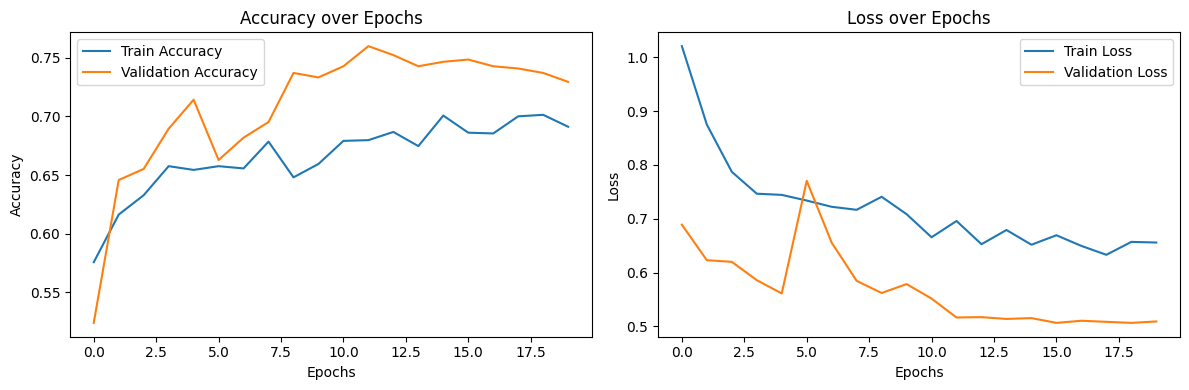

In [ ]:
# =========================================================
# 5. Model Training with Callbacks
# =========================================================

import matplotlib.pyplot as plt

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

# ---------------------------------------------------------
# Callbacks
# ---------------------------------------------------------

# Save Best Model
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Stop Training if Validation Loss Stops Improving
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Reduce Learning Rate Automatically
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

# ---------------------------------------------------------
# Train the Model
# ---------------------------------------------------------

history = model.fit(
    data_augmenter.flow(
        X_train,
        y_train,
        batch_size=32
    ),
    epochs=20,
    validation_data=(X_val, y_val),
    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ]
)

# ---------------------------------------------------------
# Plot Training History
# ---------------------------------------------------------

plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Training VGG16 Model...

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.5599 - loss: 1.1184
Epoch 1: val_accuracy improved from None to 0.62286, saving model to best_vgg16_model.h5



Epoch 1: finished saving model to best_vgg16_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 53s 648ms/step - accuracy: 0.6074 - loss: 1.0228 - val_accuracy: 0.6229 - val_loss: 0.6703 - learning_rate: 1.0000e-04
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.6382 - loss: 0.8704
Epoch 2: val_accuracy did not improve from 0.62286
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 288ms/step - accuracy: 0.6360 - loss: 0.8516 - val_accuracy: 0.6229 - val_loss: 0.7594 - learning_rate: 1.0000e-04
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.6606 - loss: 0.7911
Epoch 3: val_accuracy improved from 0.62286 to 0.72762, saving model to best_vgg16_model.h5



Epoch 3: finished saving model to best_vgg16_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 314ms/step - accuracy: 0.6582 - loss: 0.7967 - val_accuracy: 0.7276 - val_loss: 0.5331 - learning_rate: 1.0000e-04
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.6536 - loss: 0.7926
Epoch 4: val_accuracy did not improve from 0.72762
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 289ms/step - accuracy: 0.6563 - loss: 0.7679 - val_accuracy: 0.7124 - val_loss: 0.5503 - learning_rate: 1.0000e-04
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.6522 - loss: 0.7945
Epoch 5: val_accuracy did not improve from 0.72762
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 282ms/step - accuracy: 0.6525 - loss: 0.7673 - val_accuracy: 0.6990 - val_loss: 0.6059 - learning_rate: 1.0000e-04
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.6619 - loss: 0.7550
Epoch 6: val_accuracy improved from 0.72762 to 0.73524, saving model to best_vgg16_model.h5



Epoch 6: finished saving model to best_vgg16_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 302ms/step - accuracy: 0.6557 - loss: 0.7661 - val_accuracy: 0.7352 - val_loss: 0.5745 - learning_rate: 1.0000e-04
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.6311 - loss: 0.7936
Epoch 7: val_accuracy did not improve from 0.73524
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 287ms/step - accuracy: 0.6302 - loss: 0.7894 - val_accuracy: 0.7200 - val_loss: 0.6109 - learning_rate: 1.0000e-04
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.6841 - loss: 0.7026
Epoch 8: val_accuracy did not improve from 0.73524

Epoch 8: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 288ms/step - accuracy: 0.6722 - loss: 0.6982 - val_accuracy: 0.6838 - val_loss: 0.6533 - learning_rate: 1.0000e-04
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.6721 - loss: 0.7034
Epoch 9: val_accuracy did not improve from 0.73524
50/50 ━━━━━━━━━━━━

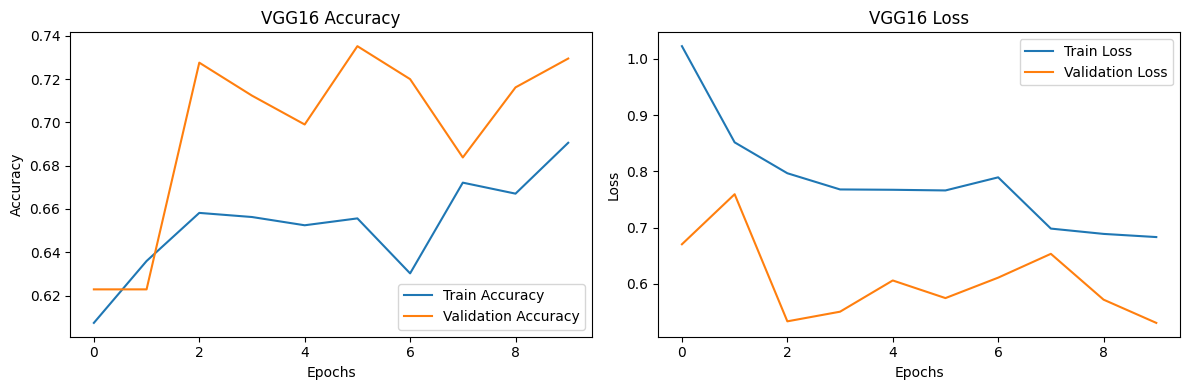


Training ResNet50 Model...

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.5283 - loss: 0.7410
Epoch 1: val_accuracy improved from None to 0.42476, saving model to best_resnet50_model.h5



Epoch 1: finished saving model to best_resnet50_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 510ms/step - accuracy: 0.5540 - loss: 0.7172 - val_accuracy: 0.4248 - val_loss: 0.7640 - learning_rate: 1.0000e-04
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.5456 - loss: 0.7041
Epoch 2: val_accuracy did not improve from 0.42476
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 205ms/step - accuracy: 0.5826 - loss: 0.6903 - val_accuracy: 0.4248 - val_loss: 1.0237 - learning_rate: 1.0000e-04
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.6226 - loss: 0.6576
Epoch 3: val_accuracy did not improve from 0.42476
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 195ms/step - accuracy: 0.6194 - loss: 0.6588 - val_accuracy: 0.4248 - val_loss: 0.8903 - learning_rate: 1.0000e-04
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.6145 - loss: 0.6733
Epoch 4: val_accuracy did not improve from 0.42476
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 212ms/step - accuracy: 0.6163 - loss: 0.6619 - val_accuracy: 0


Epoch 10: finished saving model to best_resnet50_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 222ms/step - accuracy: 0.6423 - loss: 0.6431 - val_accuracy: 0.5600 - val_loss: 0.6654 - learning_rate: 2.0000e-05
Restoring model weights from the end of the best epoch: 10.


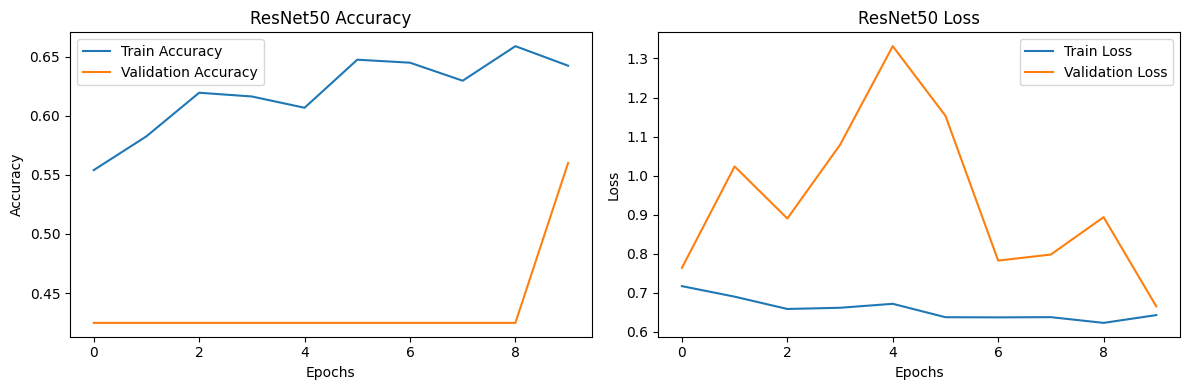

In [ ]:
# =========================================================
# 5. TRAIN VGG16 MODEL
# =========================================================

import matplotlib.pyplot as plt

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

# ---------------------------------------------------------
# Callbacks for VGG16
# ---------------------------------------------------------

checkpoint_vgg = ModelCheckpoint(
    'best_vgg16_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping_vgg = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_vgg = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

# ---------------------------------------------------------
# Train VGG16
# ---------------------------------------------------------

print("\n=================================================")
print("Training VGG16 Model...")
print("=================================================\n")

history_vgg = model.fit(
    data_augmenter.flow(
        X_train,
        y_train,
        batch_size=32
    ),
    epochs=10,
    validation_data=(X_val, y_val),
    callbacks=[
        checkpoint_vgg,
        early_stopping_vgg,
        reduce_lr_vgg
    ]
)

# ---------------------------------------------------------
# Plot VGG16 Training History
# ---------------------------------------------------------

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)

plt.plot(
    history_vgg.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history_vgg.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('VGG16 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)

plt.plot(
    history_vgg.history['loss'],
    label='Train Loss'
)

plt.plot(
    history_vgg.history['val_loss'],
    label='Validation Loss'
)

plt.title('VGG16 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


# =========================================================
# 6. TRAIN RESNET50 MODEL
# =========================================================

# ---------------------------------------------------------
# Callbacks for ResNet50
# ---------------------------------------------------------

checkpoint_resnet = ModelCheckpoint(
    'best_resnet50_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping_resnet = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_resnet = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

# ---------------------------------------------------------
# Train ResNet50
# ---------------------------------------------------------

print("\n=================================================")
print("Training ResNet50 Model...")
print("=================================================\n")

history_resnet = model_resnet.fit(
    data_augmenter.flow(
        X_train,
        y_train,
        batch_size=32
    ),
    epochs=10,
    validation_data=(X_val, y_val),
    callbacks=[
        checkpoint_resnet,
        early_stopping_resnet,
        reduce_lr_resnet
    ]
)

# ---------------------------------------------------------
# Plot ResNet50 Training History
# ---------------------------------------------------------

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)

plt.plot(
    history_resnet.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history_resnet.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('ResNet50 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)

plt.plot(
    history_resnet.history['loss'],
    label='Train Loss'
)

plt.plot(
    history_resnet.history['val_loss'],
    label='Validation Loss'
)

plt.title('ResNet50 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Evaluate VGG 16 and RESNET 50

import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report

# Load models
vgg16_model = load_model('best_vgg16_model.h5')
resnet50_model = load_model('best_resnet50_model.h5')

models = {
    "VGG16": vgg16_model,
    "ResNet50": resnet50_model
}

for model_name, model in models.items():

    print("\n" + "="*50)
    print(f"Evaluating {model_name}")
    print("="*50)

    loss, accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    print(f"Test Loss: {loss:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")

    y_pred_probs = model.predict(X_test)

    y_pred = np.argmax(
        y_pred_probs,
        axis=1
    )

    y_true = np.argmax(
        y_test,
        axis=1
    )

    print("\nClassification Report\n")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=[
                'Functional',
                'Defective'
            ]
        )
    )


Evaluating VGG16
Test Loss: 0.6161
Test Accuracy: 0.7181
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 283ms/step

Classification Report

              precision    recall  f1-score   support

  Functional       0.69      0.93      0.79       302
   Defective       0.82      0.43      0.56       223

    accuracy                           0.72       525
   macro avg       0.75      0.68      0.68       525
weighted avg       0.74      0.72      0.70       525


Evaluating ResNet50
Test Loss: 0.6800
Test Accuracy: 0.5219
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 355ms/step

Classification Report

              precision    recall  f1-score   support

  Functional       0.74      0.26      0.39       302
   Defective       0.47      0.87      0.61       223

    accuracy                           0.52       525
   macro avg       0.60      0.57      0.50       525
weighted avg       0.62      0.52      0.48       525



In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def predict_defect(image_path, model, img_size=224):

    # Read image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("Error: Image not found")
        return

    # Resize
    img = cv2.resize(img, (img_size, img_size))

    # Normalize
    img = img.astype("float32") / 255.0

    # Convert to (1, 224, 224, 1)
    img = np.expand_dims(img, axis=(0, -1))

    print("Input shape:", img.shape)

    # Prediction
    preds = model.predict(img, verbose=0)

    class_names = ['Functional', 'Defective']

    pred_class = np.argmax(preds, axis=1)[0]

    print("Prediction:", class_names[pred_class])
    print("Confidence:", float(np.max(preds)))

    # Show image
    plt.imshow(cv2.imread(image_path, cv2.IMREAD_GRAYSCALE), cmap='gray')
    plt.title(f"{class_names[pred_class]} ({np.max(preds):.2f})")
    plt.axis('off')
    plt.show()

In [ ]:
import os

print("VGG16 Size:",
      os.path.getsize("best_vgg16_model.h5")/(1024*1024),
      "MB")

print("ResNet50 Size:",
      os.path.getsize("best_resnet50_model.h5")/(1024*1024),
      "MB")

VGG16 Size: 204.78701782226562 MB
ResNet50 Size: 102.58833312988281 MB


In [ ]:
import os

print(os.listdir())


['.config', 'best_resnet50_model.h5', 'best_vgg16_model.h5', 'best_model.h5', 'sample_data']


In [ ]:
!ls -lh

total 513M
-rw-r--r-- 1 root root 205M May 31 06:49 best_model.h5
-rw-r--r-- 1 root root 103M May 31 06:44 best_resnet50_model.h5
-rw-r--r-- 1 root root 205M May 31 06:49 best_vgg16_model.h5
drwxr-xr-x 1 root root 4.0K May 26 13:25 sample_data


In [ ]:
from tensorflow.keras.models import load_model

resnet_model = load_model("best_resnet50_model.h5")
print("ResNet50 Loaded Successfully")

ResNet50 Loaded Successfully


In [ ]:
from tensorflow.keras.models import load_model

vgg_model = load_model("best_vgg16_model.h5")
print("VGG16 Loaded Successfully")

VGG16 Loaded Successfully


In [ ]:
print(model.input_shape)

(None, 224, 224, 1)


In [ ]:
vgg_model="best_vgg16_model.h5"
predict_defect("cell41.png", vgg_model)

Error: Image not found


Input shape: (1, 224, 224, 1)
Prediction: Defective
Confidence: 0.7042493224143982


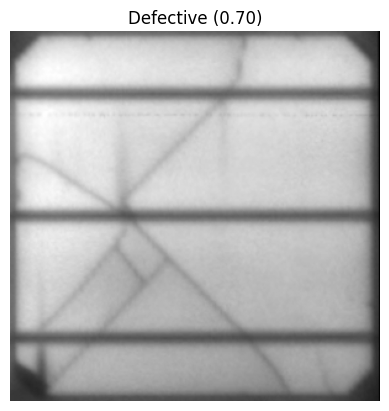

In [ ]:
predict_defect("cell0041.png", resnet_model)

Input shape: (1, 224, 224, 1)
Prediction: Defective
Confidence: 0.9399546980857849


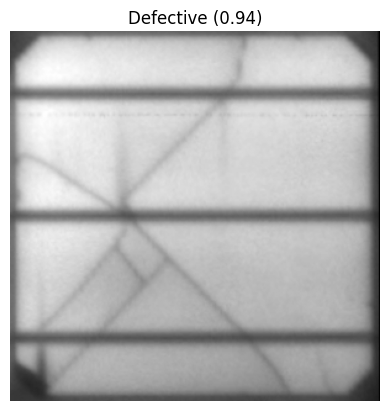

In [ ]:
predict_defect("cell0010.png", vgg_model)

Input shape: (1, 224, 224, 1)
Prediction: Functional
Confidence: 0.753993034362793


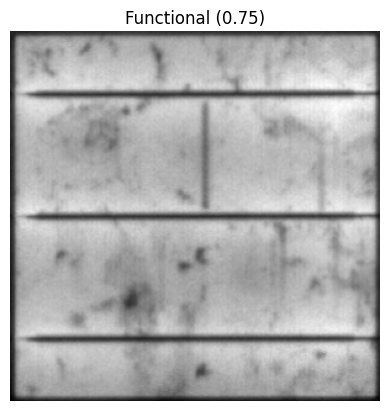

In [ ]:
predict_defect("cell2619.png", vgg_model)